**DEEP LEARNING-BASED OCULAR DISEASE DETECTION USING FUNDUS IMAGES**

In [1]:
import nbformat

# Load the notebook
nb_path = "MultiModel.ipynb"
with open(nb_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=nbformat.NO_CONVERT)

# Fix: remove or repair bad widget metadata
if "widgets" in nb.metadata:
    print("🔧 Found widget metadata — cleaning...")
    nb.metadata.pop("widgets", None)

# Remove widget metadata from cells too
for cell in nb.cells:
    if "widgets" in cell.get("metadata", {}):
        cell["metadata"].pop("widgets", None)

# Save the cleaned notebook
with open(nb_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("✅ Cleaned and saved:", nb_path)


🔧 Found widget metadata — cleaning...
✅ Cleaned and saved: MultiModel.ipynb


In [ ]:
from google.colab import drive, files
import os, shutil

# Mount Google Drive
drive.mount('/content/drive')

# Upload kaggle.json
print(" Please upload your kaggle.json file (from Kaggle account settings)")
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print(" Kaggle API key set up successfully!")

#  Create dataset path in Google Drive
dataset_path = '/content/drive/MyDrive/eye_diseases_classification'
os.makedirs(dataset_path, exist_ok=True)
os.chdir(dataset_path)

Mounted at /content/drive
 Please upload your kaggle.json file (from Kaggle account settings)


Saving kaggle.json to kaggle.json
 Kaggle API key set up successfully!


In [ ]:
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification
!unzip -q eye-diseases-classification.zip -d .
os.remove('eye-diseases-classification.zip')
dataset_dir = os.path.join(dataset_path, 'dataset')
print("Dataset classes:", os.listdir(dataset_dir))


Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
 97% 710M/736M [00:05<00:00, 124MB/s] 
100% 736M/736M [00:05<00:00, 135MB/s]
Dataset classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [ ]:
!pip install opencv-python-headless

In [ ]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

image_save_path = os.path.join(dataset_path, 'preprocessed_images')
vessel_save_path = os.path.join(dataset_path, 'vessel_masks')

os.makedirs(image_save_path, exist_ok=True)
os.makedirs(vessel_save_path, exist_ok=True)


*   Wavelet captures lesion details at multiple scales.
*   CLAHE improves contrast in darker regions.
*   Vessel mask isolates blood vessels, useful for GNN and model attention.

In [ ]:
# Preprocessing Functions
IMG_SIZE = (224, 224)
classes = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

# Wavelet Transform - enhances multi-resolution lesion details
def wavelet_transform(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    coeffs2 = pywt.dwt2(gray, 'bior1.3')
    LL, (LH, HL, HH) = coeffs2
    reconstructed = pywt.idwt2((LL, (LH, HL, HH)), 'bior1.3')
    return np.uint8(reconstructed)

# CLAHE - improves contrast
def apply_clahe(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

# Vessel segmentation - isolates vascular network
def blood_vessel_segmentation(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
    kernel = np.ones((3, 3), np.uint8)
    morphed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    return morphed


Reads images, resizes to model input size.
Applies Wavelet, CLAHE, and vessel segmentation.
Stacks channels to feed models like Conformer.
Saves .npy files for fast loading during training.

In [ ]:
def preprocess_dataset():
    for cls in classes:
        img_class_path = os.path.join(dataset_dir, cls)
        os.makedirs(os.path.join(image_save_path, cls), exist_ok=True)
        os.makedirs(os.path.join(vessel_save_path, cls), exist_ok=True)

        for img_file in tqdm(os.listdir(img_class_path), desc=f"Processing {cls}"):
            try:
                img_path = os.path.join(img_class_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.resize(img, IMG_SIZE)

                # Apply preprocessing
                wavelet_img = cv2.resize(wavelet_transform(img), IMG_SIZE)
                clahe_img = cv2.resize(apply_clahe(img), IMG_SIZE)
                vessel_mask = cv2.resize(blood_vessel_segmentation(img), IMG_SIZE)

                stacked_img = np.stack([wavelet_img, clahe_img, vessel_mask], axis=-1)

                # Save preprocessed images
                np.save(os.path.join(image_save_path, cls, img_file.split('.')[0] + '.npy'), stacked_img)
                np.save(os.path.join(vessel_save_path, cls, img_file.split('.')[0] + '_vessel.npy'), vessel_mask)

            except Exception as e:
                print(f"Error processing {img_file}: {e}")

preprocess_dataset()


Processing normal: 100%|██████████| 1074/1074 [00:38<00:00, 27.85it/s]


Bar plot shows how many images per class.

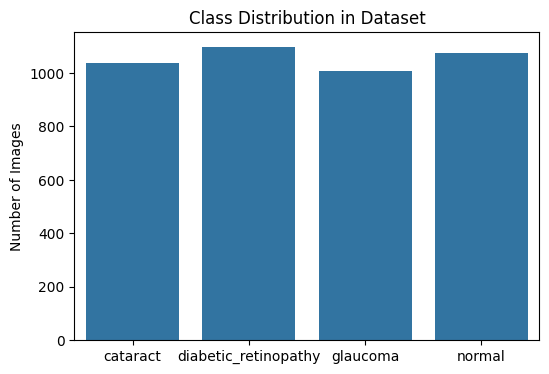

In [ ]:
# Count images per class
class_counts = {cls: len(os.listdir(os.path.join(dataset_dir, cls))) for cls in classes}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution in Dataset")
plt.ylabel("Number of Images")
plt.show()


Sample visualization demonstrates how each preprocessing step transforms the image: Original → Wavelet → CLAHE → Vessel Mask -> Stacked Image.
Helps validate preprocessing quality visually.

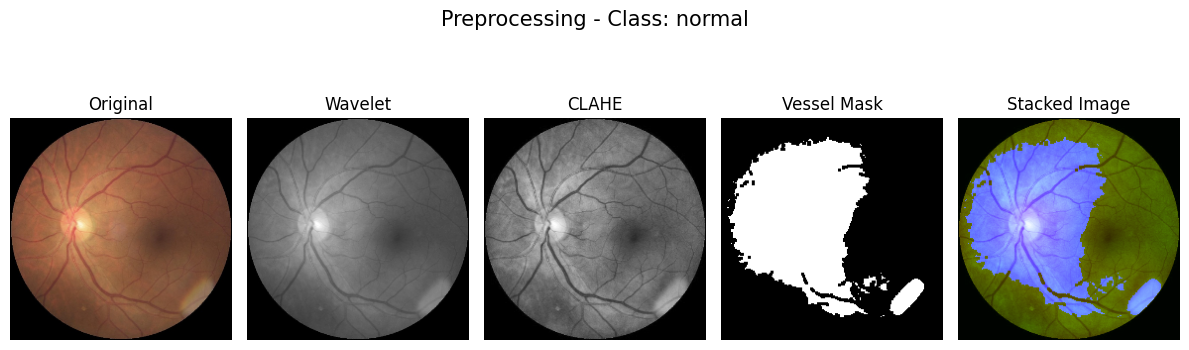

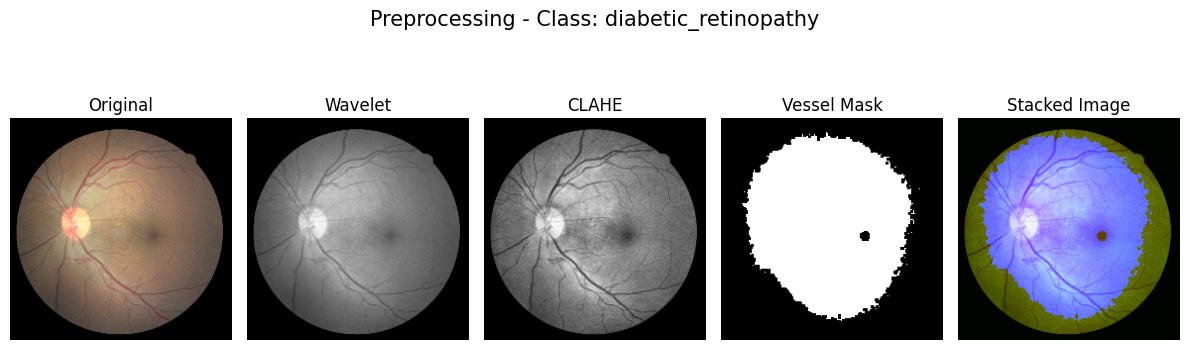

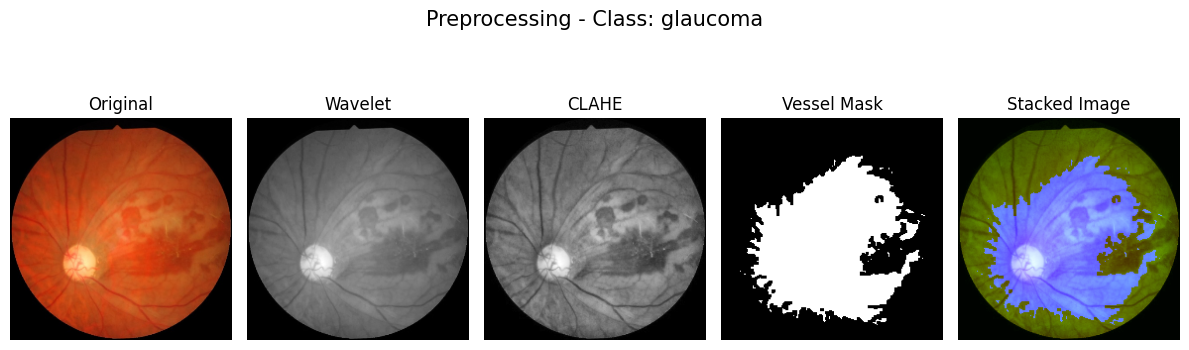

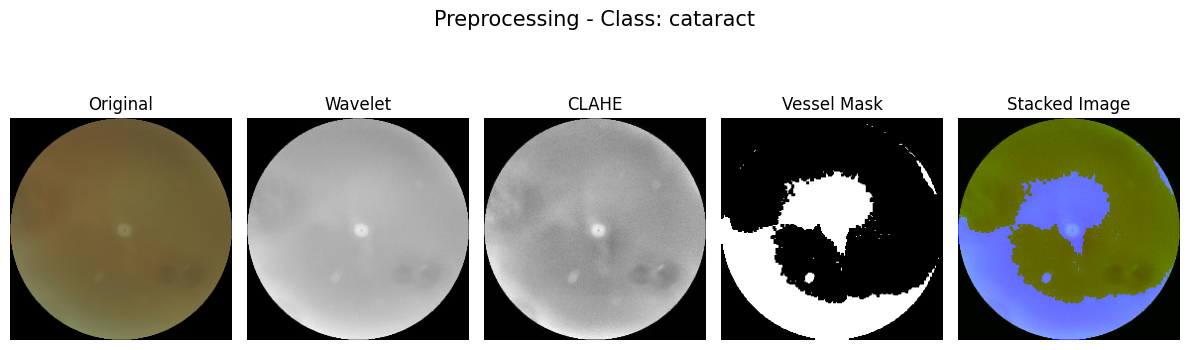

In [ ]:
def show_sample(class_name='normal'):
    sample_path = os.path.join(dataset_dir, class_name, os.listdir(os.path.join(dataset_dir, class_name))[0])
    img = cv2.imread(sample_path)
    img = cv2.resize(img, IMG_SIZE)

    # Apply preprocessing steps
    wavelet_img = wavelet_transform(img)            # Wavelet Transform
    clahe_img = apply_clahe(img)                    # CLAHE
    vessel_mask = blood_vessel_segmentation(img)    # Vessel Segmentation

    # Stack the three channels
    stacked_img = np.stack([wavelet_img, clahe_img, vessel_mask], axis=-1)
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Preprocessing - Class: {class_name}", fontsize=15)

    plt.subplot(1, 5, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(wavelet_img, cmap='gray')
    plt.title("Wavelet")
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(clahe_img, cmap='gray')
    plt.title("CLAHE")
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(vessel_mask, cmap='gray')
    plt.title("Vessel Mask")
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(stacked_img.astype('uint8'))
    plt.title("Stacked Image")
    plt.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_sample('normal')
show_sample('diabetic_retinopathy')
show_sample('glaucoma')
show_sample('cataract')


Box plot shows vessel intensity variation across classes.
Can reveal differences in vascular patterns among normal and diseased eyes.
Useful for exploratory data analysis (EDA) before modeling.

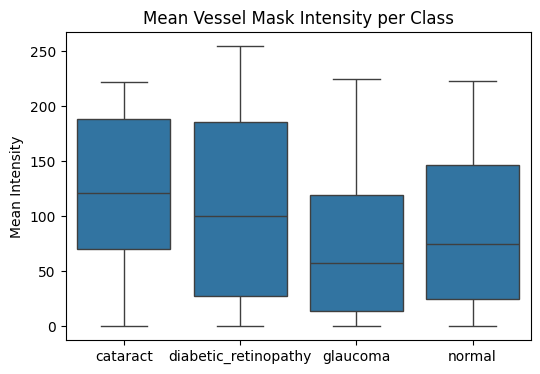

In [ ]:
# Feature Distribution Visualization
mean_intensity = []
class_labels = []

for cls in classes:
    vessel_dir = os.path.join(vessel_save_path, cls)
    for file in os.listdir(vessel_dir):
        mask = np.load(os.path.join(vessel_dir, file))
        mean_intensity.append(np.mean(mask))
        class_labels.append(cls)

plt.figure(figsize=(6, 4))
sns.boxplot(x=class_labels, y=mean_intensity)
plt.title("Mean Vessel Mask Intensity per Class")
plt.ylabel("Mean Intensity")
plt.show()


In [ ]:
#Feature Fusion and Extraction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Dataset Loader

class EyeDataset(Dataset):
    def __init__(self, image_dir, vessel_dir, classes, transform=None):
        self.samples = []
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        for cls in classes:
            img_cls_dir = os.path.join(image_dir, cls)
            ves_cls_dir = os.path.join(vessel_dir, cls)
            for f in os.listdir(img_cls_dir):
                if f.endswith('.npy'):
                    img_path = os.path.join(img_cls_dir, f)
                    ves_path = os.path.join(ves_cls_dir, f.replace('.npy', '_vessel.npy'))
                    self.samples.append((img_path, ves_path, self.class_to_idx[cls]))

        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ves_path, label = self.samples[idx]
        img = np.load(img_path)
        vessel = np.load(ves_path)

        # Normalize
        img = img.astype(np.float32) / 255.0
        vessel = vessel.astype(np.float32) / 255.0

        # Convert to torch
        img = torch.tensor(img).permute(2,0,1)
        vessel = torch.tensor(vessel).unsqueeze(0)

        return img, vessel, label


Conformer Model

In [ ]:
class VisionBackbone(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, embed_dim, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.flatten = nn.Flatten(2)
        self.transpose = lambda x: x.transpose(1,2)

    def forward(self, x):
        x = self.cnn(x)
        x = self.flatten(x)
        x = self.transpose(x)
        return x

GNN Graph Embeddings

In [ ]:
import torch_geometric
from torch_geometric.nn import GCNConv, global_mean_pool

class GraphBackbone(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=128, out_dim=128):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return global_mean_pool(x, batch).unsqueeze(1)


Cross Attention Fusion Layer(GNN+Conformer)

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim=None, dropout=0.1):
        super().__init__()
        hidden_dim = hidden_dim or 4 * dim
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x): return self.net(x)

In [ ]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim_visual, dim_graph, dim_hidden=256, num_heads=8, dropout=0.1, bidirectional=True):
        super().__init__()
        self.dim_out = dim_hidden
        self.proj_v = nn.Linear(dim_visual, self.dim_out)
        self.proj_g = nn.Linear(dim_graph, self.dim_out)
        self.cross_attn_v2g = nn.MultiheadAttention(embed_dim=self.dim_out, num_heads=num_heads, batch_first=True)
        self.cross_attn_g2v = nn.MultiheadAttention(embed_dim=self.dim_out, num_heads=num_heads, batch_first=True) if bidirectional else None
        self.norm_v1, self.norm_g1 = nn.LayerNorm(self.dim_out), nn.LayerNorm(self.dim_out)
        self.ffn_v, self.ffn_g = FeedForward(self.dim_out), FeedForward(self.dim_out)
        self.norm_v2, self.norm_g2 = nn.LayerNorm(self.dim_out), nn.LayerNorm(self.dim_out)
        self.out_v, self.out_g = nn.Linear(self.dim_out, dim_visual), nn.Linear(self.dim_out, dim_graph)
    def forward(self, v, g):
        v, g = self.proj_v(v), self.proj_g(g)
        attn_v, _ = self.cross_attn_v2g(v, g, g)
        v = self.norm_v1(v + attn_v)
        if self.cross_attn_g2v:
            attn_g, _ = self.cross_attn_g2v(g, v, v)
            g = self.norm_g1(g + attn_g)
        v = self.norm_v2(v + self.ffn_v(v))
        g = self.norm_g2(g + self.ffn_g(g))
        return self.out_v(v), self.out_g(g)

In [ ]:
class EyeDiseaseNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.vision = VisionBackbone(embed_dim=512)
        self.gnn = GraphBackbone(in_dim=1, hidden_dim=128, out_dim=128)
        self.fusion = CrossAttentionFusion(dim_visual=512, dim_graph=128, dim_hidden=256)
        self.classifier = nn.Linear(512+128, num_classes)

    def forward(self, img, vessel_graph, return_features=False):
        v_tokens = self.vision(img)
        g_before = vessel_graph

        # Fusion
        v_fused, g_after = self.fusion(v_tokens, g_before)

        # Pooling
        v_pooled = v_fused.mean(dim=1)
        g_pooled = g_after.mean(dim=1)

        fused = torch.cat([v_pooled, g_pooled], dim=-1)
        out = self.classifier(fused)

        if return_features:
            return out, v_tokens, v_fused, g_before, g_after
        else:
            return out


In [ ]:
def visualize_feature_extraction(model, dataset, idx=0):
    model.eval()
    img, vessel, label = dataset[idx]
    img_in = img.unsqueeze(0).to(device)

    g_embed = torch.randn(1,1,128).to(device)

    with torch.no_grad():
        out, v_tokens, v_fused, g_before, g_after = model(
            img_in, g_embed, return_features=True
        )

    # Show stacked image + vessel mask
    fig, axs = plt.subplots(1,2, figsize=(8,4))
    axs[0].imshow(img.permute(1,2,0).cpu().numpy())
    axs[0].set_title("Stacked Preprocessed Image")
    axs[0].axis("off")
    axs[1].imshow(vessel.squeeze().cpu().numpy(), cmap="gray")
    axs[1].set_title("Vessel Mask")
    axs[1].axis("off")
    plt.show()

    # Visual tokens before vs after fusion
    v_pca = PCA(2).fit_transform(v_tokens.squeeze(0).cpu().numpy())
    v_fused_pca = PCA(2).fit_transform(v_fused.squeeze(0).cpu().numpy())
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(v_pca[:,0], v_pca[:,1], c="blue")
    plt.title("Visual Tokens Before Fusion")
    plt.subplot(1,2,2)
    plt.scatter(v_fused_pca[:,0], v_fused_pca[:,1], c="red")
    plt.title("Visual Tokens After Fusion")
    plt.show()

    # Graph embedding before vs after
    plt.figure(figsize=(6,3))
    sns.heatmap([g_before.squeeze(0).cpu().numpy().flatten(),
                 g_after.squeeze(0).cpu().numpy().flatten()],
                cmap="viridis", yticklabels=["Graph Before","Graph After"])
    plt.title("Graph Embeddings")
    plt.show()


Visualization Before Model Training

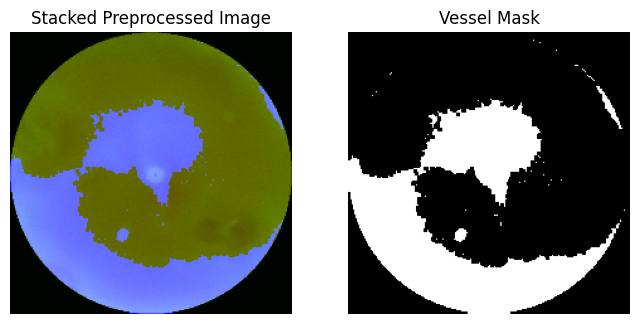

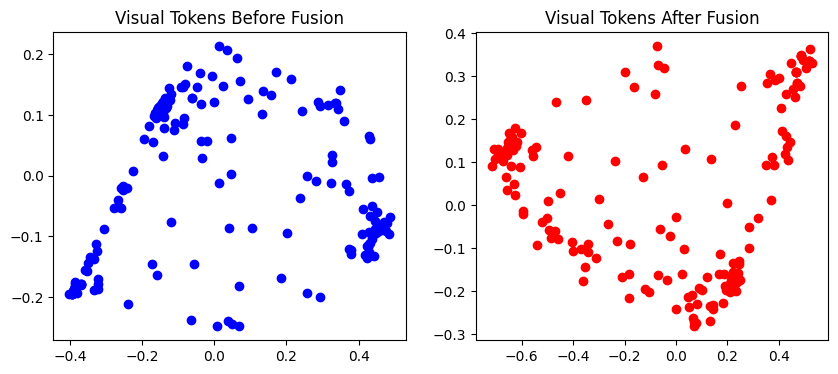

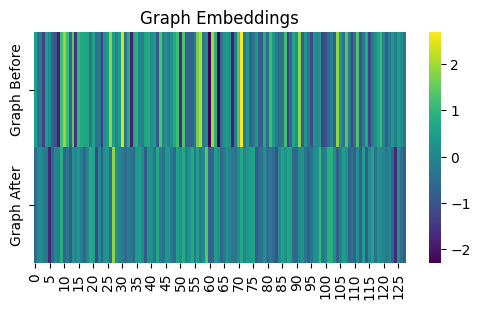

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataset = EyeDataset(image_save_path, vessel_save_path, classes)

num_classes = len(classes)
model = EyeDiseaseNet(num_classes=num_classes).to(device)

visualize_feature_extraction(model, train_dataset, idx=0)


In [ ]:
from sklearn.model_selection import train_test_split

all_indices = list(range(len(train_dataset)))

# Split indices into train and val
train_idx, val_idx = train_test_split(all_indices, test_size=0.2, stratify=[s[2] for s in train_dataset.samples], random_state=42)

# Subset datasets
from torch.utils.data import Subset
train_dataset_split = Subset(train_dataset, train_idx)
val_dataset = Subset(train_dataset, val_idx)

# Dataloaders
batch_size = 16
train_loader = DataLoader(train_dataset_split, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
from sklearn.metrics import classification_report
import torch.nn.functional as F

def train_model(model, train_loader, val_loader, num_epochs=10, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_acc_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        #  Training
        model.train()
        correct, total = 0, 0
        for imgs, vessels, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            g_embed = torch.randn(imgs.size(0), 1, 128).to(device)

            optimizer.zero_grad()
            outputs = model(imgs, g_embed)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_acc_history.append(train_acc)

        # Validation
        model.eval()
        correct, total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, vessels, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                g_embed = torch.randn(imgs.size(0), 1, 128).to(device)

                outputs = model(imgs, g_embed)
                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = correct / total
        val_acc_history.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    print("\nClassification Report (Validation):")
    print(classification_report(all_labels, all_preds, target_names=classes))

    return train_acc_history, val_acc_history


In [ ]:
num_classes = len(classes)
model = EyeDiseaseNet(num_classes=num_classes).to(device)

train_acc, val_acc = train_model(model, train_loader, val_loader, num_epochs=20, lr=1e-4)


Epoch [1/20] - Train Acc: 0.3647, Val Acc: 0.4206
Epoch [2/20] - Train Acc: 0.4708, Val Acc: 0.4810
Epoch [3/20] - Train Acc: 0.5384, Val Acc: 0.5818
Epoch [4/20] - Train Acc: 0.5998, Val Acc: 0.5024
Epoch [5/20] - Train Acc: 0.6528, Val Acc: 0.5273
Epoch [6/20] - Train Acc: 0.6905, Val Acc: 0.7121
Epoch [7/20] - Train Acc: 0.6994, Val Acc: 0.7358
Epoch [8/20] - Train Acc: 0.7243, Val Acc: 0.7287
Epoch [9/20] - Train Acc: 0.7287, Val Acc: 0.7441
Epoch [10/20] - Train Acc: 0.7489, Val Acc: 0.7393
Epoch [11/20] - Train Acc: 0.7566, Val Acc: 0.7156
Epoch [12/20] - Train Acc: 0.7714, Val Acc: 0.7583
Epoch [13/20] - Train Acc: 0.7711, Val Acc: 0.7986
Epoch [14/20] - Train Acc: 0.7857, Val Acc: 0.7713
Epoch [15/20] - Train Acc: 0.7854, Val Acc: 0.7867
Epoch [16/20] - Train Acc: 0.7963, Val Acc: 0.7453
Epoch [17/20] - Train Acc: 0.7996, Val Acc: 0.7832
Epoch [18/20] - Train Acc: 0.7975, Val Acc: 0.7642
Epoch [19/20] - Train Acc: 0.8014, Val Acc: 0.7453
Epoch [20/20] - Train Acc: 0.8091, Val A

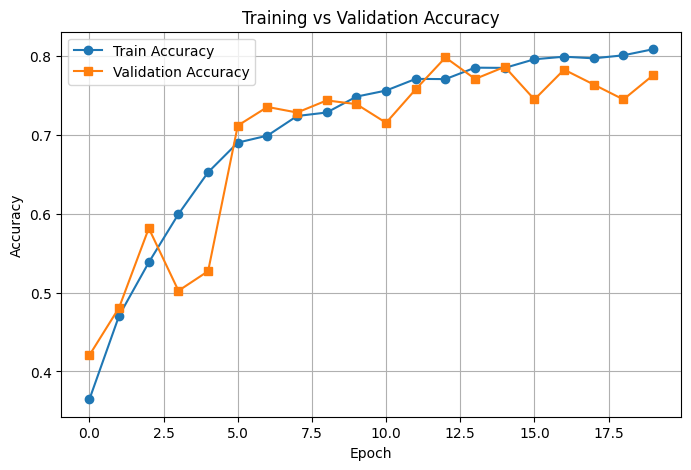

In [ ]:
def plot_training_curves(train_acc_history, val_acc_history):
    plt.figure(figsize=(8,5))
    plt.plot(train_acc_history, label="Train Accuracy", marker='o')
    plt.plot(val_acc_history, label="Validation Accuracy", marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_curves(train_acc, val_acc)


Visualization After Model Training

 AFTER TRAINING


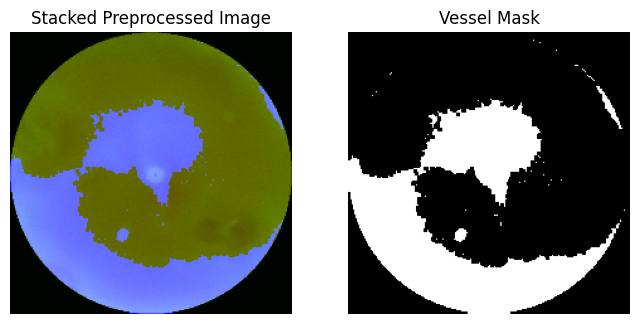

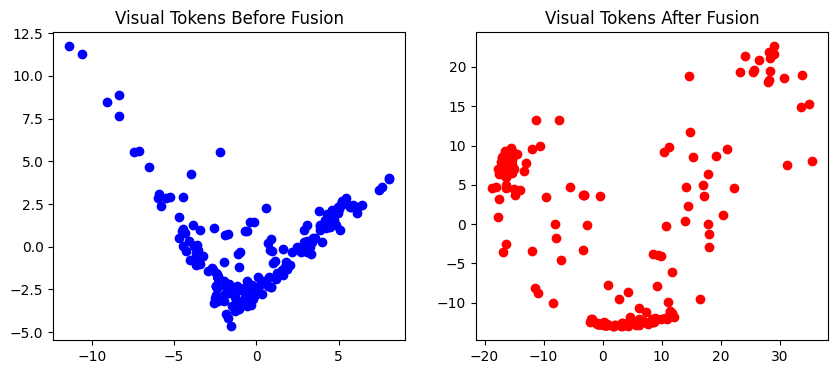

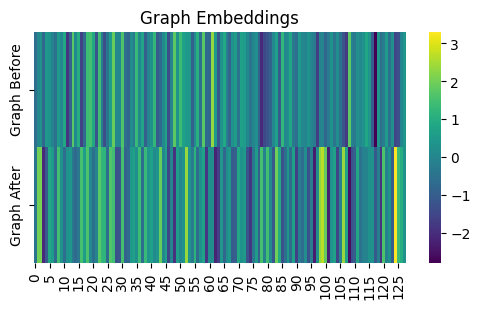

In [ ]:
idx = 0
print(" AFTER TRAINING")
visualize_feature_extraction(model, train_dataset, idx=idx)


In [ ]:
idx = 0
sample_img, _, sample_label = train_dataset[idx]
sample_img_tensor = sample_img.unsqueeze(0).to(device)
orig_img = tensor_to_img(sample_img_tensor)

g_embed = torch.randn(1,1,128).to(device)

#Forward function for Captum that injects the GNN embedding
def forward_with_gnn(x):
    return model(x, g_embed)

XAI Techniques on GNN-Conformer Model

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import LayerGradCam, IntegratedGradients

# Function to convert tensor to RGB image
def tensor_to_img(tensor):
    img = tensor.cpu().squeeze().permute(1,2,0).numpy()
    img = (img * 255).astype(np.uint8)
    return img

# Function to overlay heatmap
def overlay_heatmap_on_image(orig_img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_HOT):
    heatmap_resized = cv2.resize(heatmap, (orig_img.shape[1], orig_img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap_resized), colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(orig_img, 1-alpha, heatmap_color, alpha, 0)
    return superimposed

#  Pick a sample from validation set
sample_img, _, sample_label = val_dataset[5]
sample_img_tensor = sample_img.unsqueeze(0).to(device)
orig_img = tensor_to_img(sample_img_tensor)

Grad-CAM

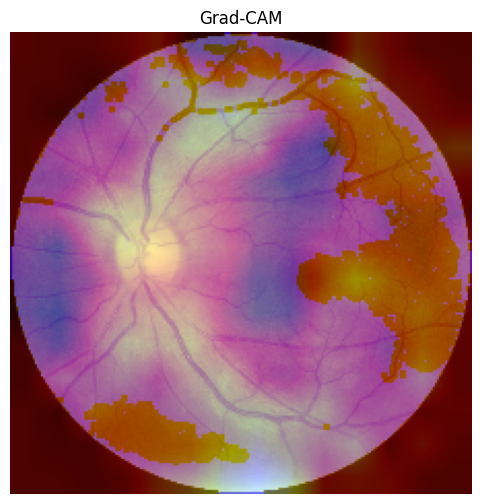

In [ ]:

target_layer = model.vision.cnn[-1]  # last ReLU
gradcam = LayerGradCam(forward_with_gnn, target_layer)
attr_gc = gradcam.attribute(sample_img_tensor, target=sample_label)
heatmap_gc = attr_gc[0].sum(dim=0).cpu().detach().numpy()
heatmap_gc = (heatmap_gc - heatmap_gc.min()) / (heatmap_gc.max() - heatmap_gc.min())
superimposed_gc = overlay_heatmap_on_image(orig_img, heatmap_gc)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_gc)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()


Saliency Map

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


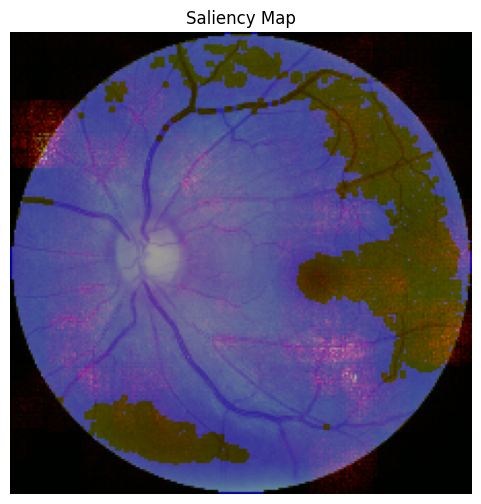

In [ ]:
saliency = Saliency(forward_with_gnn)
attr_sal = saliency.attribute(sample_img_tensor, target=sample_label)
heatmap_sal = attr_sal[0].sum(dim=0).cpu().detach().numpy()
heatmap_sal = (heatmap_sal - heatmap_sal.min()) / (heatmap_sal.max() - heatmap_sal.min())
superimposed_sal = overlay_heatmap_on_image(orig_img, heatmap_sal)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_sal)
plt.axis('off')
plt.title("Saliency Map")
plt.show()

LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

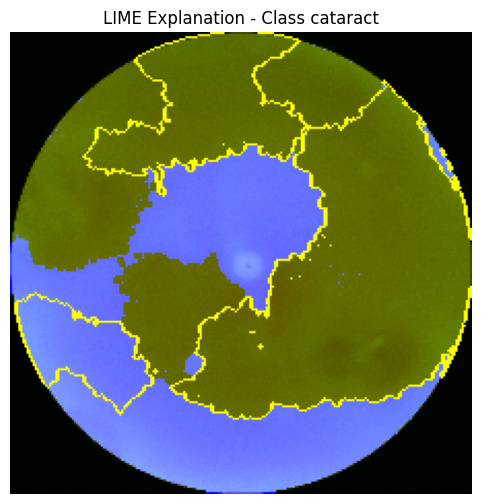

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

idx = 0
sample_img, _, sample_label = train_dataset[idx]
sample_img_np = (sample_img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
g_embed = torch.randn(1,1,128).to(device)

#  prediction function for LIME
def predict_fn(images):
    model.eval()
    batch = []
    for img in images:
        img_tensor = torch.tensor(img/255., dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)
        out = model(img_tensor, g_embed)
        probs = torch.softmax(out, dim=1).cpu().detach().numpy()
        batch.append(probs[0])
    return np.array(batch)

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Explain prediction
explanation = explainer.explain_instance(
    sample_img_np,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Get explanation for the predicted class
pred_class = np.argmax(predict_fn([sample_img_np]))
temp, mask = explanation.get_image_and_mask(
    label=pred_class,
    positive_only=True,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)

# Overlay explanation
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp/255.0, mask))
plt.title(f"LIME Explanation - Class {classes[pred_class]}")
plt.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import LayerGradCam, IntegratedGradients, Saliency, DeepLift

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
train_idx, val_idx = train_test_split(list(range(len(train_dataset))),
                                      test_size=0.2,
                                      stratify=[s[2] for s in train_dataset.samples],
                                      random_state=42)
train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=16, shuffle=True)
val_loader   = DataLoader(Subset(train_dataset, val_idx), batch_size=16, shuffle=False)

Model Training, Evaluation, and Visualization functions

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.show()

def plot_learning_curve(train_acc, val_acc, title="Training vs Validation Accuracy"):
    plt.figure(figsize=(8,5))
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_roc(y_true, y_scores, classes, title="ROC Curve"):
    y_true_bin = label_binarize(y_true, classes=range(len(classes)))
    plt.figure(figsize=(8,5))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_scores[:,i])
        plt.plot(fpr, tpr, label=f"{classes[i]}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

def train_evaluate_model(model, train_loader, val_loader, num_epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        #  Training
        model.train()
        correct, total = 0, 0
        for imgs, vessels, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            g_embed = torch.randn(imgs.size(0), 1, 128).to(device)
            optimizer.zero_grad()
            outputs = model(imgs, g_embed) if hasattr(model, "gnn") else model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc_hist.append(correct/total)

        #  Validation
        model.eval()
        correct, total = 0, 0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for imgs, vessels, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                g_embed = torch.randn(imgs.size(0), 1, 128).to(device)
                outputs = model(imgs, g_embed) if hasattr(model, "gnn") else model(imgs)
                probs = F.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
        val_acc_hist.append(correct/total)
        print(f"Epoch {epoch+1}/{num_epochs} - Train Acc: {train_acc_hist[-1]:.4f}, Val Acc: {val_acc_hist[-1]:.4f}")
    return train_acc_hist, val_acc_hist, all_labels, all_preds, np.array(all_probs)

ResNet50

In [ ]:
from torchvision import models

# Initialize pretrained ResNet50
model_resnet = models.resnet50(pretrained=True)
num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, len(classes))  # 4 eye classes
model_resnet = model_resnet.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
train_acc, val_acc, all_labels, all_preds, all_probs = train_evaluate_model(
    model_resnet, train_loader, val_loader, num_epochs=10, lr=1e-4
)


Epoch 1/10 - Train Acc: 0.9194, Val Acc: 0.8874
Epoch 2/10 - Train Acc: 0.9508, Val Acc: 0.8472
Epoch 3/10 - Train Acc: 0.9736, Val Acc: 0.9052
Epoch 4/10 - Train Acc: 0.9751, Val Acc: 0.8756
Epoch 5/10 - Train Acc: 0.9819, Val Acc: 0.9005
Epoch 6/10 - Train Acc: 0.9881, Val Acc: 0.8981
Epoch 7/10 - Train Acc: 0.9902, Val Acc: 0.8969
Epoch 8/10 - Train Acc: 0.9887, Val Acc: 0.9076
Epoch 9/10 - Train Acc: 0.9873, Val Acc: 0.9064
Epoch 10/10 - Train Acc: 0.9917, Val Acc: 0.8555


In [ ]:
print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

Final Training Accuracy: 0.9917
Final Validation Accuracy: 0.8555


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report (Validation Set):")
print(classification_report(all_labels, all_preds, target_names=classes))

Classification Report (Validation Set):
                      precision    recall  f1-score   support

            cataract       0.89      0.90      0.90       208
diabetic_retinopathy       0.95      1.00      0.98       220
            glaucoma       0.71      0.84      0.77       201
              normal       0.87      0.68      0.76       215

            accuracy                           0.86       844
           macro avg       0.86      0.85      0.85       844
        weighted avg       0.86      0.86      0.85       844



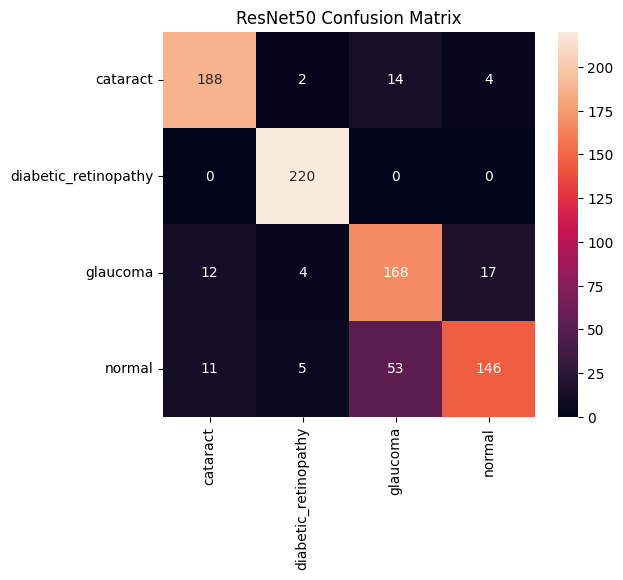

In [ ]:
plot_confusion_matrix(all_labels, all_preds, classes, title="ResNet50 Confusion Matrix")


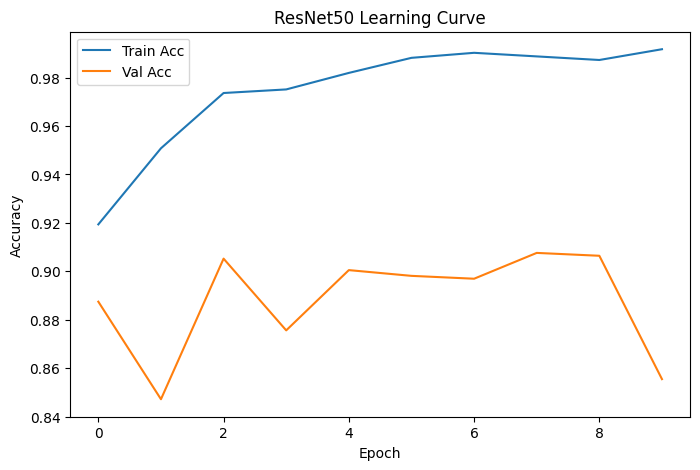

In [ ]:
plot_learning_curve(train_acc, val_acc, title="ResNet50 Learning Curve")


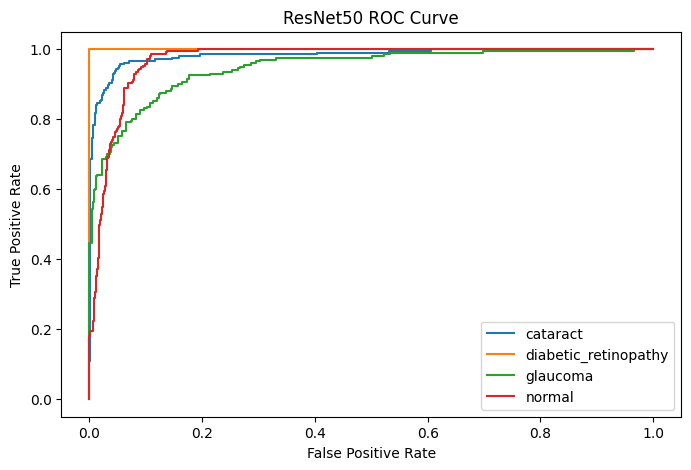

In [ ]:
plot_roc(all_labels, all_probs, classes, title="ResNet50 ROC Curve")

XAI Techniques on ResNet50

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import LayerGradCam, IntegratedGradients

#Convert tensor to RGB image
def tensor_to_img(tensor):
    img = tensor.cpu().squeeze().permute(1,2,0).numpy()
    img = (img * 255).astype(np.uint8)
    return img

#  Function to overlay heatmap
def overlay_heatmap_on_image(orig_img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_HOT):
    heatmap_resized = cv2.resize(heatmap, (orig_img.shape[1], orig_img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap_resized), colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(orig_img, 1-alpha, heatmap_color, alpha, 0)
    return superimposed

sample_img, _, sample_label = val_dataset[1]
sample_img_tensor = sample_img.unsqueeze(0).to(device)
orig_img = tensor_to_img(sample_img_tensor)

Grad-CAM

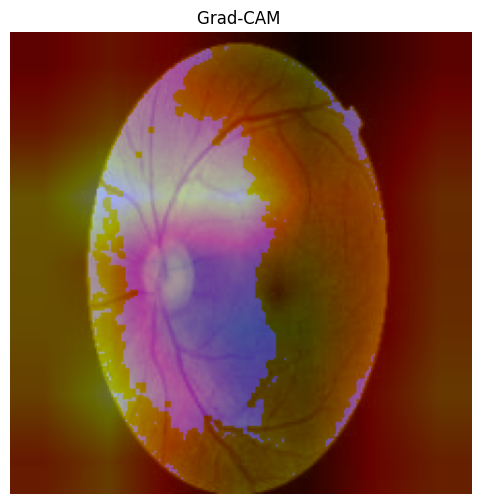

In [ ]:
# Choose last conv layer of ResNet50
target_layer = model_resnet.layer4[-1].conv2
gradcam = LayerGradCam(model_resnet, target_layer)

attr_gc = gradcam.attribute(sample_img_tensor, target=sample_label)
heatmap_gc = attr_gc[0].sum(dim=0).cpu().detach().numpy()
heatmap_gc = (heatmap_gc - heatmap_gc.min()) / (heatmap_gc.max() - heatmap_gc.min())  # normalize

# Overlay Grad-CAM
superimposed_gc = overlay_heatmap_on_image(orig_img, heatmap_gc, alpha=0.4, colormap=cv2.COLORMAP_HOT)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_gc)
plt.title("Grad-CAM ")
plt.axis('off')
plt.show()

Integrated Gradients

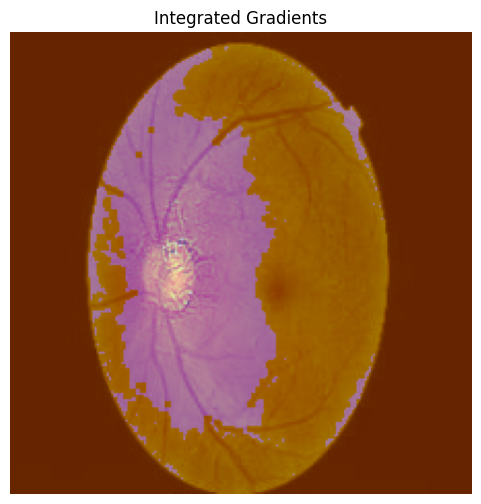

In [ ]:
ig = IntegratedGradients(model_resnet)
attr_ig = ig.attribute(sample_img_tensor, target=sample_label, n_steps=50)
heatmap_ig = attr_ig[0].sum(dim=0).cpu().detach().numpy()
heatmap_ig = (heatmap_ig - heatmap_ig.min()) / (heatmap_ig.max() - heatmap_ig.min())  # normalize

# Overlay IG
superimposed_ig = overlay_heatmap_on_image(orig_img, heatmap_ig, alpha=0.4, colormap=cv2.COLORMAP_HOT)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_ig)
plt.title("Integrated Gradients")
plt.axis('off')
plt.show()

Saliency Map

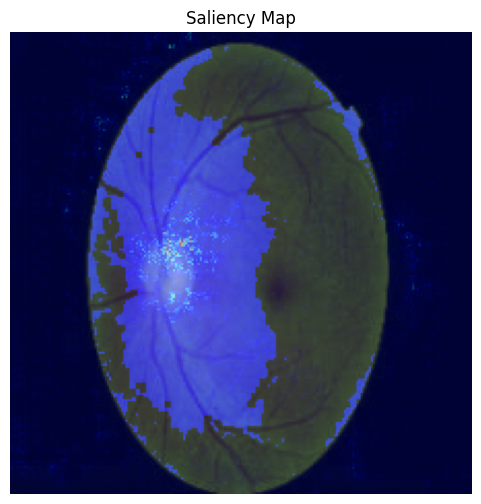

In [ ]:
from captum.attr import Saliency

saliency = Saliency(model_resnet)
attr_saliency = saliency.attribute(sample_img_tensor, target=sample_label)
heatmap_saliency = attr_saliency[0].sum(dim=0).cpu().detach().numpy()
heatmap_saliency = (heatmap_saliency - heatmap_saliency.min()) / (heatmap_saliency.max() - heatmap_saliency.min())

superimposed_saliency = overlay_heatmap_on_image(orig_img, heatmap_saliency, alpha=0.4, colormap=cv2.COLORMAP_JET)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_saliency)
plt.title("Saliency Map")
plt.axis('off')
plt.show()


In [ ]:
!pip install lime --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

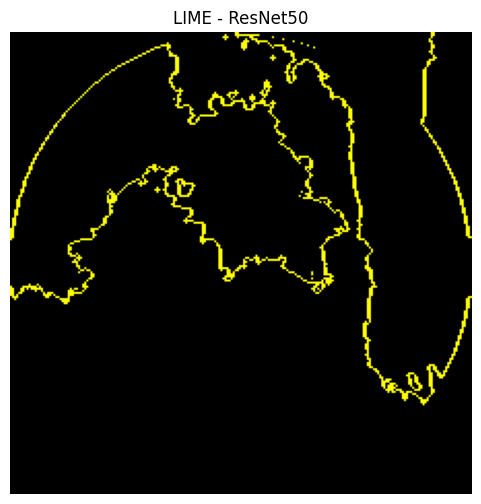

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

sample_img, _, sample_label = val_dataset[0]
sample_img_tensor = sample_img.unsqueeze(0).to(device)

img_np = sample_img_tensor.squeeze().permute(1,2,0).cpu().numpy()

def predict_fn(images_np, model):
    model.eval()
    imgs_tensor = torch.tensor(images_np).permute(0,3,1,2).float().to(device)
    with torch.no_grad():
        outputs = model(imgs_tensor) if not hasattr(model, "gnn") else model(imgs_tensor, torch.randn(imgs_tensor.size(0), 1, 128).to(device))
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# LIME explainer
explainer = lime_image.LimeImageExplainer()

#  Explain for ResNet
explanation_resnet = explainer.explain_instance(
    image=img_np,
    classifier_fn=lambda x: predict_fn(x, model_resnet),
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Get image and mask for top label
temp, mask = explanation_resnet.get_image_and_mask(
    label=sample_label,
    positive_only=True,
    num_features=10,
    hide_rest=False
)
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp/255.0, mask))
plt.title("LIME - ResNet50")
plt.axis('off')
plt.show()



Efficientnet B0

In [ ]:
num_classes = len(classes)
model_effnet = models.efficientnet_b0(pretrained=True)
model_effnet.classifier[1] = nn.Linear(model_effnet.classifier[1].in_features, num_classes)
model_effnet = model_effnet.to(device)

In [ ]:
train_acc, val_acc, all_labels, all_preds, all_probs = train_evaluate_model(
    model_effnet, train_loader, val_loader, num_epochs=10, lr=1e-4
)


Epoch 1/10 - Train Acc: 0.7702, Val Acc: 0.8898
Epoch 2/10 - Train Acc: 0.9001, Val Acc: 0.9017
Epoch 3/10 - Train Acc: 0.9357, Val Acc: 0.9017
Epoch 4/10 - Train Acc: 0.9449, Val Acc: 0.8945
Epoch 5/10 - Train Acc: 0.9641, Val Acc: 0.9076
Epoch 6/10 - Train Acc: 0.9790, Val Acc: 0.9076
Epoch 7/10 - Train Acc: 0.9813, Val Acc: 0.9111
Epoch 8/10 - Train Acc: 0.9801, Val Acc: 0.9088
Epoch 9/10 - Train Acc: 0.9864, Val Acc: 0.9028
Epoch 10/10 - Train Acc: 0.9899, Val Acc: 0.9052


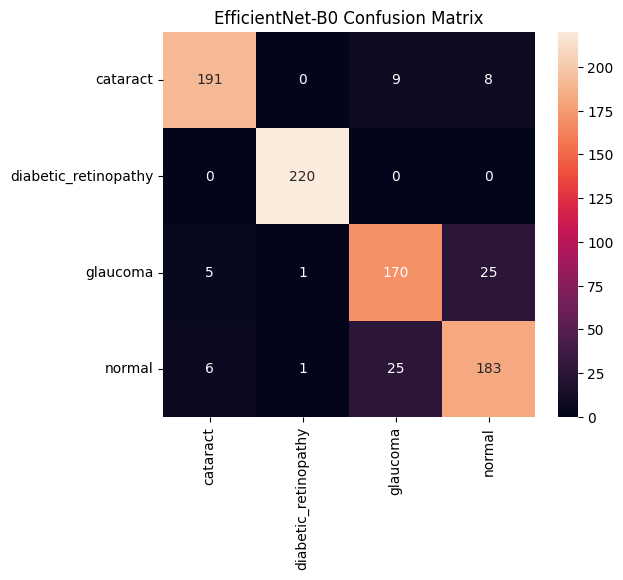

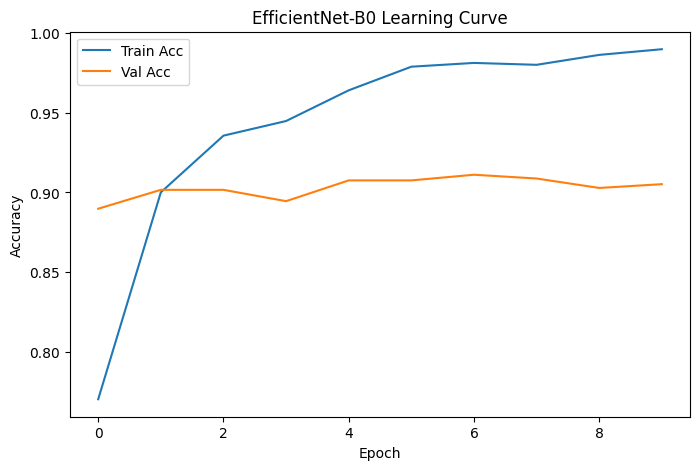

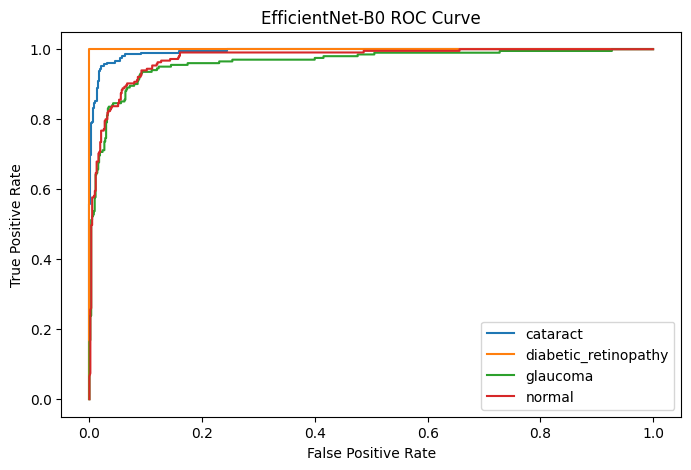

In [ ]:
# ---------------- Plots ----------------
plot_confusion_matrix(all_labels, all_preds, classes, title="EfficientNet-B0 Confusion Matrix")
plot_learning_curve(train_acc, val_acc, title="EfficientNet-B0 Learning Curve")
plot_roc(all_labels, all_probs, classes, title="EfficientNet-B0 ROC Curve")

In [ ]:
from sklearn.metrics import classification_report

all_labels, all_preds = [], []
model_effnet.eval()
with torch.no_grad():
    for batch in val_loader:
        if len(batch) == 3:
            imgs, _, labels = batch
        else:
            imgs, labels = batch

        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model_effnet(imgs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=classes))


                      precision    recall  f1-score   support

            cataract       0.95      0.92      0.93       208
diabetic_retinopathy       0.99      1.00      1.00       220
            glaucoma       0.83      0.85      0.84       201
              normal       0.85      0.85      0.85       215

            accuracy                           0.91       844
           macro avg       0.90      0.90      0.90       844
        weighted avg       0.91      0.91      0.91       844



Xai Techniques on Efficientnet B0

LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

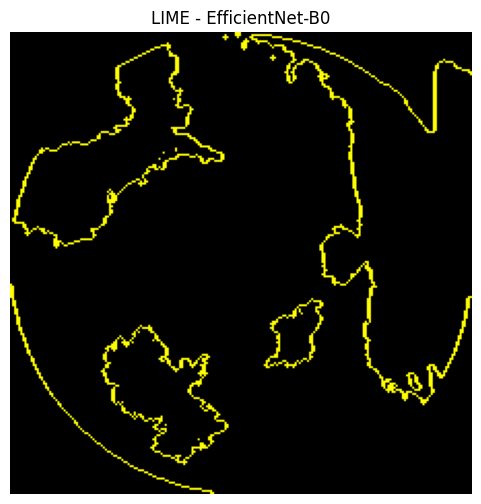

In [ ]:
explanation_effnet = explainer.explain_instance(
    image=img_np,
    classifier_fn=lambda x: predict_fn(x, model_effnet),
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation_effnet.get_image_and_mask(
    label=sample_label,
    positive_only=True,
    num_features=10,
    hide_rest=False
)
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp/255.0, mask))
plt.title("LIME - EfficientNet-B0")
plt.axis('off')
plt.show()

Grad-CAM

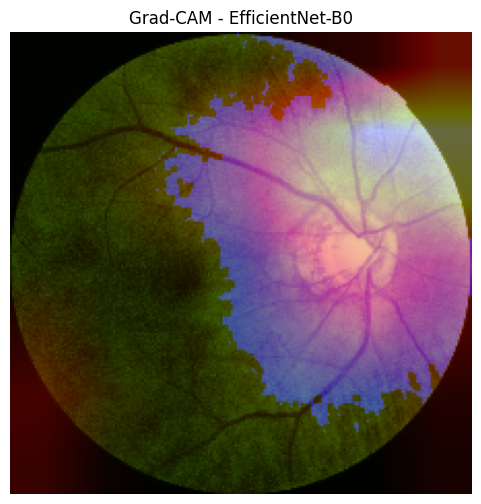

In [ ]:
sample_img, _, sample_label = val_dataset[0]
sample_img_tensor = sample_img.unsqueeze(0).to(device)
orig_img = tensor_to_img(sample_img_tensor)

target_layer = model_effnet.features[-1]  # last conv block
gradcam = LayerGradCam(model_effnet, target_layer)
attr_gc = gradcam.attribute(sample_img_tensor, target=sample_label)
heatmap_gc = attr_gc[0].sum(dim=0).cpu().detach().numpy()
heatmap_gc = (heatmap_gc - heatmap_gc.min()) / (heatmap_gc.max() - heatmap_gc.min())
superimposed_gc = overlay_heatmap_on_image(orig_img, heatmap_gc, alpha=0.4, colormap=cv2.COLORMAP_HOT)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_gc)
plt.title("Grad-CAM - EfficientNet-B0")
plt.axis('off')
plt.show()


Integrated Gradients

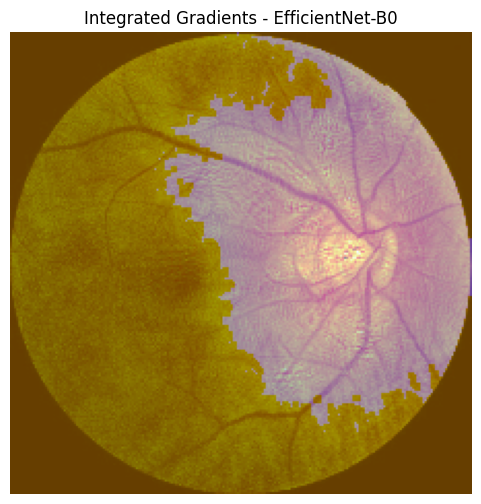

In [ ]:
ig = IntegratedGradients(model_effnet)
attr_ig = ig.attribute(sample_img_tensor, target=sample_label, n_steps=50)
heatmap_ig = attr_ig[0].sum(dim=0).cpu().detach().numpy()
heatmap_ig = (heatmap_ig - heatmap_ig.min()) / (heatmap_ig.max() - heatmap_ig.min())
superimposed_ig = overlay_heatmap_on_image(orig_img, heatmap_ig, alpha=0.4, colormap=cv2.COLORMAP_HOT)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_ig)
plt.title("Integrated Gradients - EfficientNet-B0")
plt.axis('off')
plt.show()


Saliency Map

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


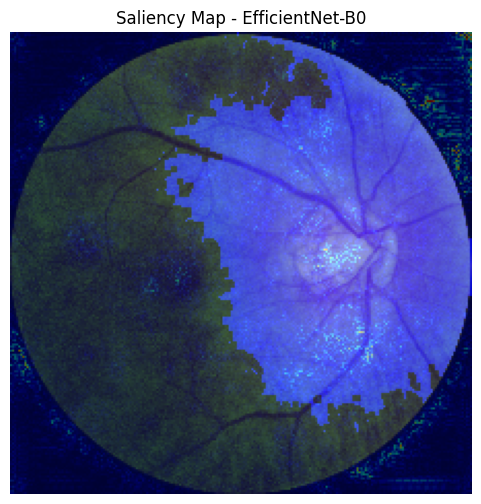

In [ ]:
saliency = Saliency(model_effnet)
attr_saliency = saliency.attribute(sample_img_tensor, target=sample_label)
heatmap_saliency = attr_saliency[0].sum(dim=0).cpu().detach().numpy()
heatmap_saliency = (heatmap_saliency - heatmap_saliency.min()) / (heatmap_saliency.max() - heatmap_saliency.min())
superimposed_saliency = overlay_heatmap_on_image(orig_img, heatmap_saliency, alpha=0.4, colormap=cv2.COLORMAP_JET)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_saliency)
plt.title("Saliency Map - EfficientNet-B0")
plt.axis('off')
plt.show()

Occlusion Sensitivity

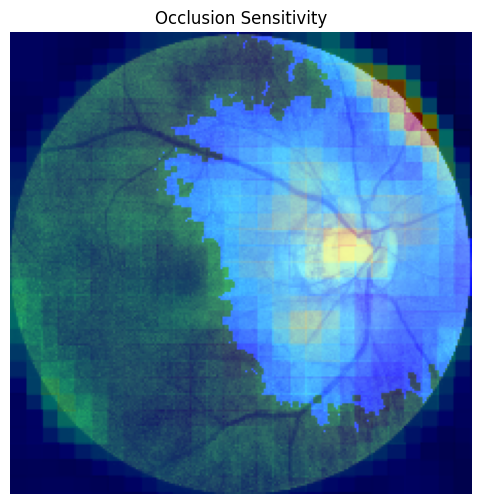

In [ ]:
from captum.attr import Occlusion, GuidedBackprop, NoiseTunnel
occlusion = Occlusion(model_effnet)
# Sliding window size: 15x15, stride: 8
attr_occ = occlusion.attribute(sample_img_tensor, target=sample_label, sliding_window_shapes=(3,15,15), strides=(3,8,8))
heatmap_occ = attr_occ[0].sum(dim=0).cpu().detach().numpy()
heatmap_occ = (heatmap_occ - heatmap_occ.min()) / (heatmap_occ.max() - heatmap_occ.min())

superimposed_occ = overlay_heatmap_on_image(orig_img, heatmap_occ, alpha=0.4, colormap=cv2.COLORMAP_JET)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_occ)
plt.title("Occlusion Sensitivity")
plt.axis('off')
plt.show()

Guided Backpropagation

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:63: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


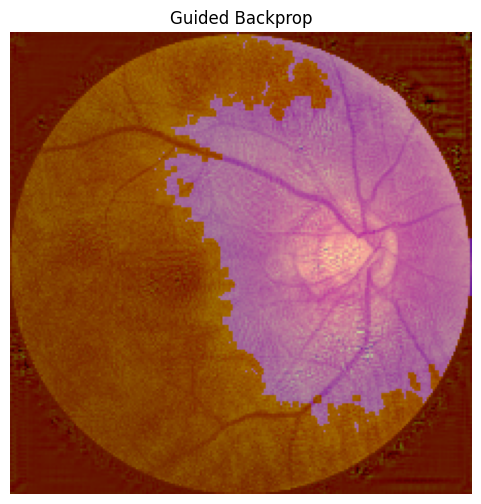

In [ ]:
gbp = GuidedBackprop(model_effnet)
attr_gbp = gbp.attribute(sample_img_tensor, target=sample_label)
heatmap_gbp = attr_gbp[0].sum(dim=0).cpu().detach().numpy()
heatmap_gbp = (heatmap_gbp - heatmap_gbp.min()) / (heatmap_gbp.max() - heatmap_gbp.min())

superimposed_gbp = overlay_heatmap_on_image(orig_img, heatmap_gbp, alpha=0.4, colormap=cv2.COLORMAP_HOT)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_gbp)
plt.title("Guided Backprop")
plt.axis('off')
plt.show()


Gradient SHAP

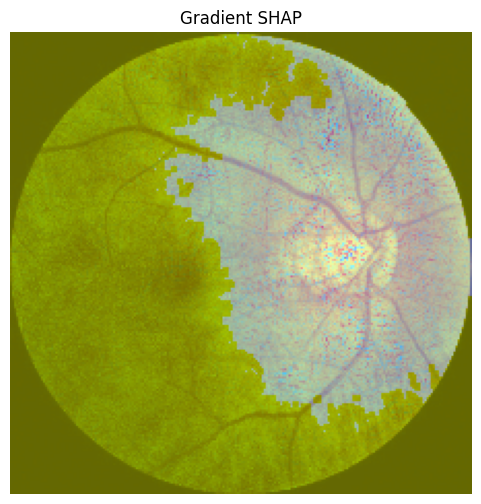

In [ ]:
gradient_shap = GradientShap(model_effnet)
baselines = torch.zeros_like(sample_img_tensor)
attr_gs = gradient_shap.attribute(
    sample_img_tensor,
    baselines=baselines,
    target=sample_label,
    n_samples=10,
    stdevs=0.01
)
heatmap_gs = normalize_heatmap(attr_gs)
show_heatmap(orig_img, heatmap_gs, "Gradient SHAP")

ViT model

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights

class ViTClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.backbone = vit_b_16(weights=weights)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x, g=None):
        return self.backbone(x)

In [ ]:
num_classes = len(classes)
model_vit = ViTClassifier(num_classes=num_classes).to(device)

In [ ]:

train_acc, val_acc, all_labels, all_preds, all_probs = train_evaluate_model(
    model_vit, train_loader, val_loader, num_epochs=10, lr=1e-4
)

Epoch 1/10 - Train Acc: 0.7673, Val Acc: 0.8483
Epoch 2/10 - Train Acc: 0.8535, Val Acc: 0.7429
Epoch 3/10 - Train Acc: 0.8936, Val Acc: 0.8649
Epoch 4/10 - Train Acc: 0.9217, Val Acc: 0.8543
Epoch 5/10 - Train Acc: 0.9330, Val Acc: 0.8649
Epoch 6/10 - Train Acc: 0.9434, Val Acc: 0.8720
Epoch 7/10 - Train Acc: 0.9540, Val Acc: 0.8697
Epoch 8/10 - Train Acc: 0.9564, Val Acc: 0.8341
Epoch 9/10 - Train Acc: 0.9573, Val Acc: 0.8519
Epoch 10/10 - Train Acc: 0.9742, Val Acc: 0.8709


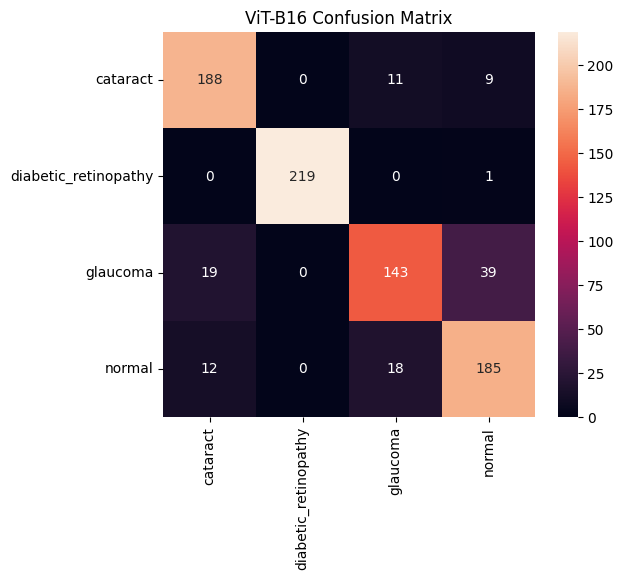

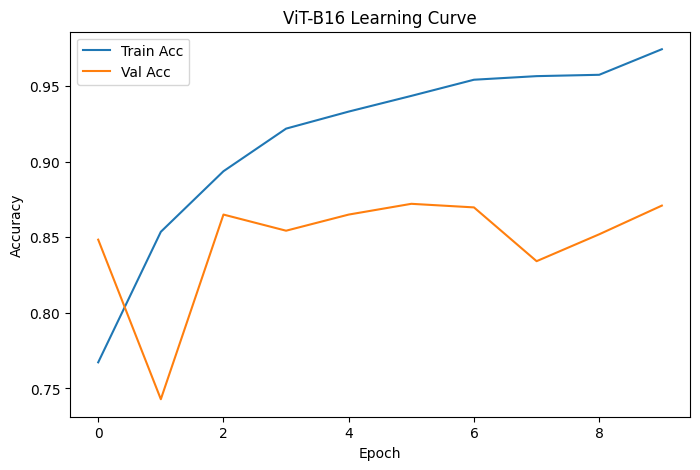

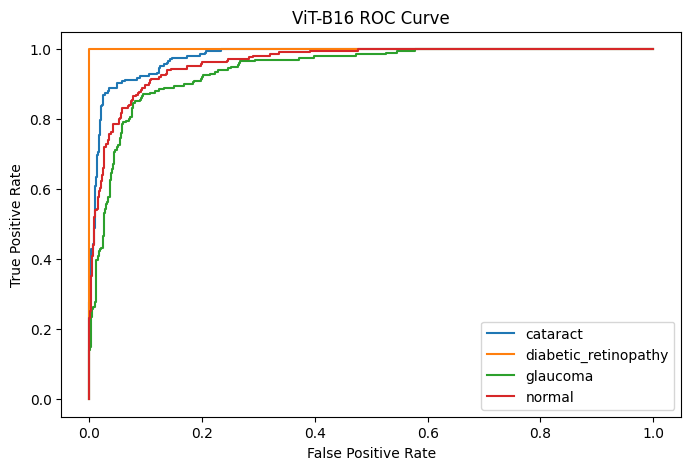

                      precision    recall  f1-score   support

            cataract       0.86      0.90      0.88       208
diabetic_retinopathy       1.00      1.00      1.00       220
            glaucoma       0.83      0.71      0.77       201
              normal       0.79      0.86      0.82       215

            accuracy                           0.87       844
           macro avg       0.87      0.87      0.87       844
        weighted avg       0.87      0.87      0.87       844



In [ ]:
# Confusion Matrix and Learning Curves
plot_confusion_matrix(all_labels, all_preds, classes, title="ViT-B16 Confusion Matrix")
plot_learning_curve(train_acc, val_acc, title="ViT-B16 Learning Curve")
plot_roc(all_labels, all_probs, classes, title="ViT-B16 ROC Curve")

# Classification Report
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=classes))

In [ ]:
sample_img, _, sample_label = val_dataset[3]
sample_img_tensor = sample_img.unsqueeze(0).to(device)
orig_img = tensor_to_img(sample_img_tensor)

XAI Techniques on Vit Model

Saliency Map

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


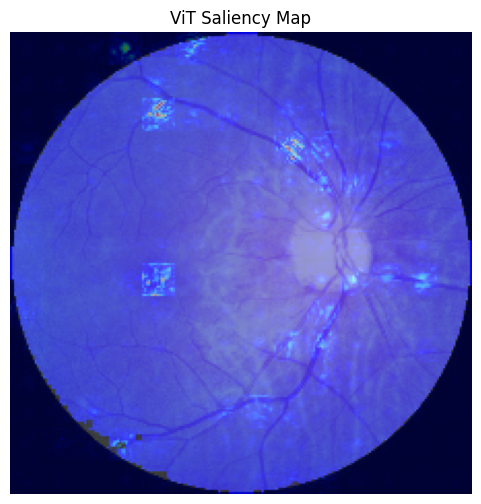

In [ ]:
saliency = Saliency(model_vit)
attr_sal = saliency.attribute(sample_img_tensor, target=sample_label)
heatmap_sal = attr_sal[0].sum(dim=0).cpu().detach().numpy()
heatmap_sal = (heatmap_sal - heatmap_sal.min()) / (heatmap_sal.max() - heatmap_sal.min())

superimposed_sal = overlay_heatmap_on_image(orig_img, heatmap_sal)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_sal)
plt.title("ViT Saliency Map")
plt.axis('off')
plt.show()

Integrated Gradients

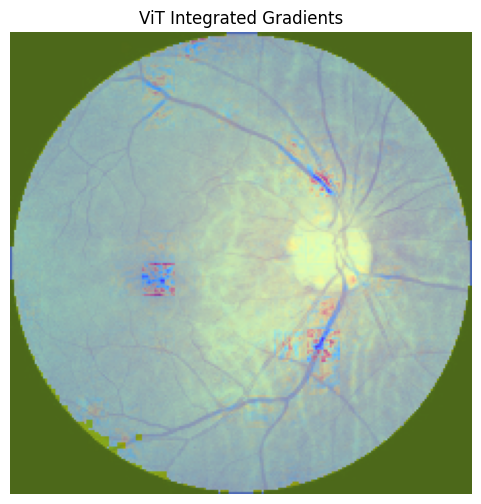

In [ ]:
ig = IntegratedGradients(model_vit)
attr_ig = ig.attribute(sample_img_tensor, target=sample_label, n_steps=50)
heatmap_ig = attr_ig[0].sum(dim=0).cpu().detach().numpy()
heatmap_ig = (heatmap_ig - heatmap_ig.min()) / (heatmap_ig.max() - heatmap_ig.min())

superimposed_ig = overlay_heatmap_on_image(orig_img, heatmap_ig)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_ig)
plt.title("ViT Integrated Gradients")
plt.axis('off')
plt.show()

Occlusion Sensitivity

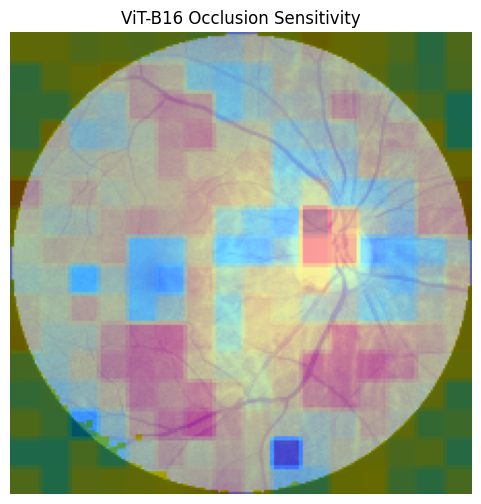

In [ ]:
occlusion = Occlusion(model_vit)
attr_occ = occlusion.attribute(
    sample_img_tensor,
    strides=(3,14,14),
    sliding_window_shapes=(3,16,16),
    target=sample_label
)
heatmap_occ = normalize_heatmap(attr_occ)
show_heatmap(orig_img, heatmap_occ, "ViT-B16 Occlusion Sensitivity")

Attention Rollout

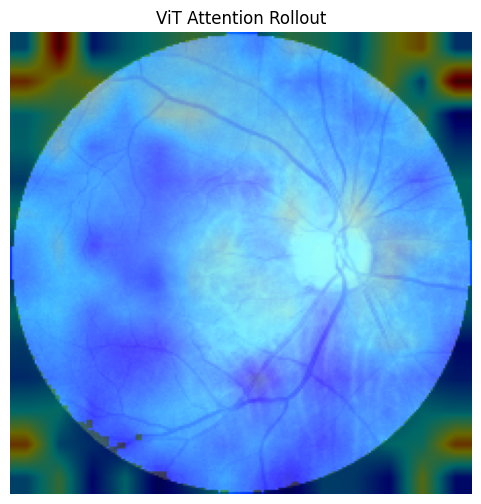

In [ ]:
def attention_rollout(model, input_tensor, discard_ratio=0.9):
    # extract attention from vit model
    with torch.no_grad():
        x = model.patch_embed(input_tensor)
        cls_token = model.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + model.pos_embed
        for blk in model.blocks:
            x = blk(x)
        # get attention weights from all heads
        attn_map = x[:,1:,:].mean(dim=-1)
        attn_map = attn_map[0].cpu().numpy()
        attn_map = attn_map.reshape(int(np.sqrt(attn_map.shape[0])),
                                    int(np.sqrt(attn_map.shape[0])))
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
        return attn_map

heatmap_attn = attention_rollout(model_vit, sample_img_tensor)
superimposed_attn = overlay_heatmap_on_image(orig_img, heatmap_attn, alpha=0.4, colormap=cv2.COLORMAP_JET)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_attn)
plt.title("ViT Attention Rollout")
plt.axis('off')
plt.show()

VGG19 Model

In [ ]:
class VGG19Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vgg19 = models.vgg19(pretrained=True)
        self.vgg19.classifier[6] = nn.Linear(4096, num_classes)
    def forward(self, x):
        return self.vgg19(x)

num_classes = len(classes)
model_vgg19 = VGG19Classifier(num_classes=num_classes).to(device)

#  Training
train_acc, val_acc, all_labels, all_preds, all_probs = train_evaluate_model(
    model_vgg19, train_loader, val_loader, num_epochs=10, lr=1e-4
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 107MB/s]


Epoch 1/10 - Train Acc: 0.7768, Val Acc: 0.8412
Epoch 2/10 - Train Acc: 0.8847, Val Acc: 0.8341
Epoch 3/10 - Train Acc: 0.9128, Val Acc: 0.8827
Epoch 4/10 - Train Acc: 0.9286, Val Acc: 0.8685
Epoch 5/10 - Train Acc: 0.9481, Val Acc: 0.8934
Epoch 6/10 - Train Acc: 0.9508, Val Acc: 0.8863
Epoch 7/10 - Train Acc: 0.9564, Val Acc: 0.8709
Epoch 8/10 - Train Acc: 0.9532, Val Acc: 0.8910
Epoch 9/10 - Train Acc: 0.9748, Val Acc: 0.9005
Epoch 10/10 - Train Acc: 0.9751, Val Acc: 0.8969


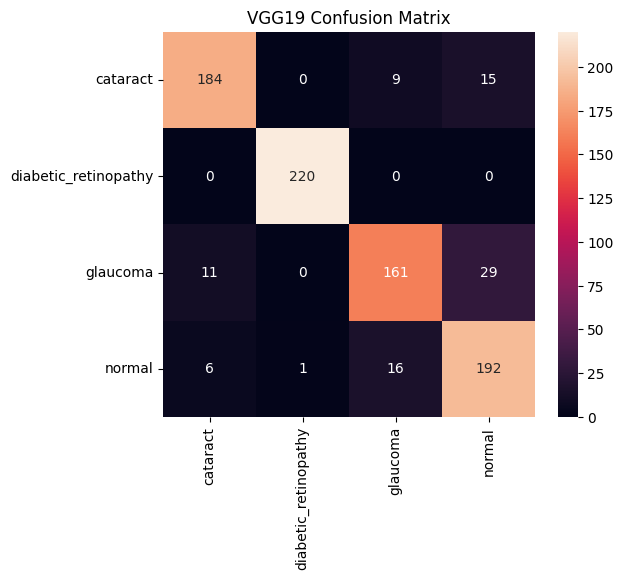

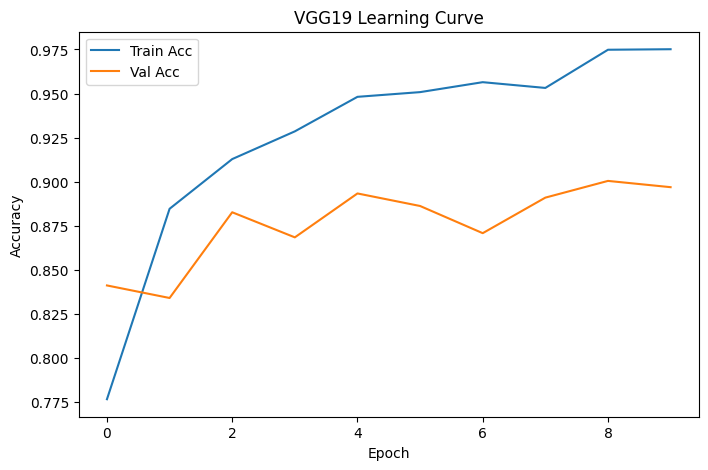

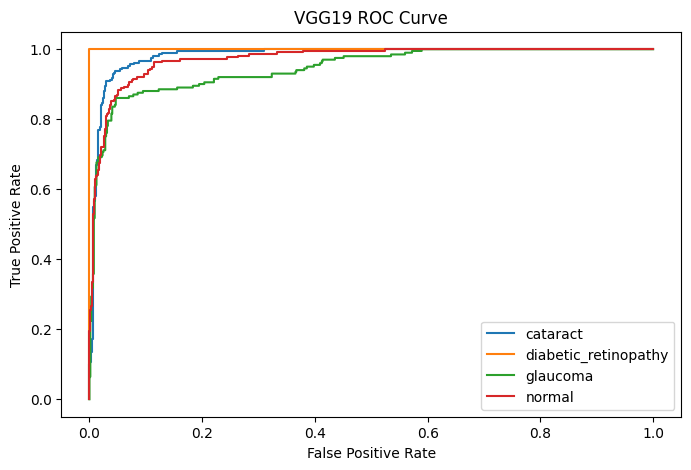


Classification Report:
                      precision    recall  f1-score   support

            cataract       0.92      0.88      0.90       208
diabetic_retinopathy       1.00      1.00      1.00       220
            glaucoma       0.87      0.80      0.83       201
              normal       0.81      0.89      0.85       215

            accuracy                           0.90       844
           macro avg       0.90      0.89      0.90       844
        weighted avg       0.90      0.90      0.90       844



In [ ]:
plot_confusion_matrix(all_labels, all_preds, classes, title="VGG19 Confusion Matrix")
plot_learning_curve(train_acc, val_acc, title="VGG19 Learning Curve")
plot_roc(all_labels, all_probs, classes, title="VGG19 ROC Curve")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


In [ ]:
sample_img, _, sample_label = val_dataset[10]
sample_img_tensor = sample_img.unsqueeze(0).to(device)
orig_img = tensor_to_img(sample_img_tensor)


Grad-CAM

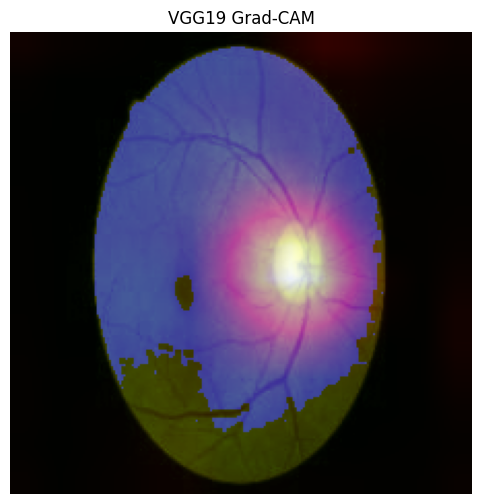

In [ ]:
sample_img, _, sample_label = val_dataset[10]
sample_img_tensor = sample_img.unsqueeze(0).to(device)
orig_img = tensor_to_img(sample_img_tensor)
target_layer = model_vgg19.vgg19.features[35]  # Last conv layer
gradcam = LayerGradCam(model_vgg19, target_layer)
attr_gc = gradcam.attribute(sample_img_tensor, target=sample_label)
heatmap_gc = attr_gc[0].sum(dim=0).cpu().detach().numpy()
heatmap_gc = (heatmap_gc - heatmap_gc.min()) / (heatmap_gc.max() - heatmap_gc.min())
superimposed_gc = overlay_heatmap_on_image(orig_img, heatmap_gc, alpha=0.4)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_gc)
plt.title("VGG19 Grad-CAM")
plt.axis('off')
plt.show()

Integrated Gradients

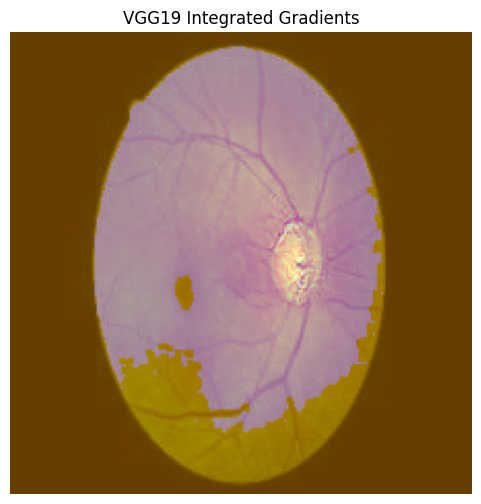

In [ ]:
ig = IntegratedGradients(model_vgg19)
attr_ig = ig.attribute(sample_img_tensor, target=sample_label, n_steps=50)
heatmap_ig = attr_ig[0].sum(dim=0).cpu().detach().numpy()
heatmap_ig = (heatmap_ig - heatmap_ig.min()) / (heatmap_ig.max() - heatmap_ig.min())
superimposed_ig = overlay_heatmap_on_image(orig_img, heatmap_ig, alpha=0.4)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_ig)
plt.title("VGG19 Integrated Gradients")
plt.axis('off')
plt.show()


 Saliency Map

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


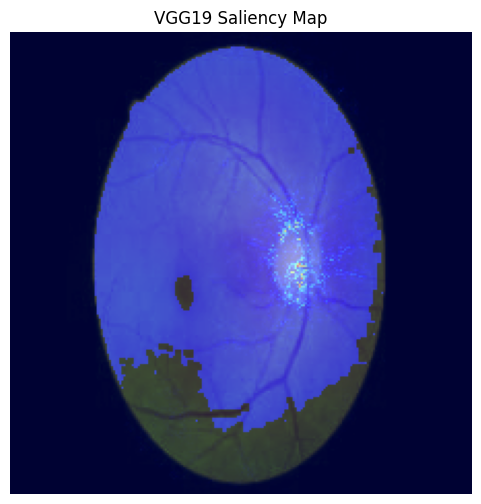

In [ ]:
saliency = Saliency(model_vgg19)
attr_saliency = saliency.attribute(sample_img_tensor, target=sample_label)
heatmap_saliency = attr_saliency[0].sum(dim=0).cpu().detach().numpy()
heatmap_saliency = (heatmap_saliency - heatmap_saliency.min()) / (heatmap_saliency.max() - heatmap_saliency.min())
superimposed_saliency = overlay_heatmap_on_image(orig_img, heatmap_saliency, alpha=0.4, colormap=cv2.COLORMAP_JET)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_saliency)
plt.title("VGG19 Saliency Map")
plt.axis('off')
plt.show()


Gradient SHAP

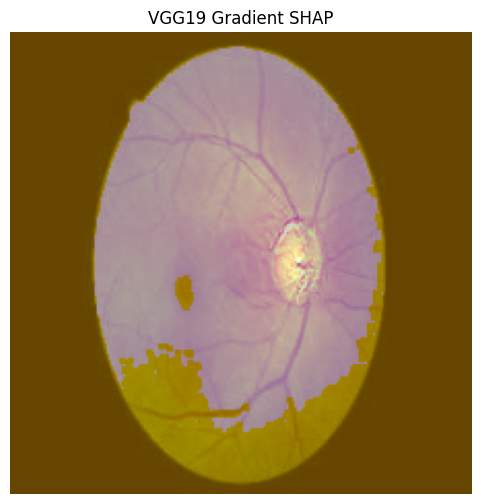

In [ ]:
gradient_shap = GradientShap(model_vgg19)
baselines = torch.zeros_like(sample_img_tensor)
attr_gs = gradient_shap.attribute(
    sample_img_tensor,
    baselines=baselines,
    target=sample_label,
    n_samples=10,
    stdevs=0.01
)
heatmap_gs = attr_gs[0].sum(dim=0).cpu().detach().numpy()
heatmap_gs = (heatmap_gs - heatmap_gs.min()) / (heatmap_gs.max() - heatmap_gs.min())

superimposed_gs = overlay_heatmap_on_image(orig_img, heatmap_gs, alpha=0.4, colormap=cv2.COLORMAP_HOT)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_gs)
plt.title("VGG19 Gradient SHAP")
plt.axis('off')
plt.show()


Occlusion Sensitivity

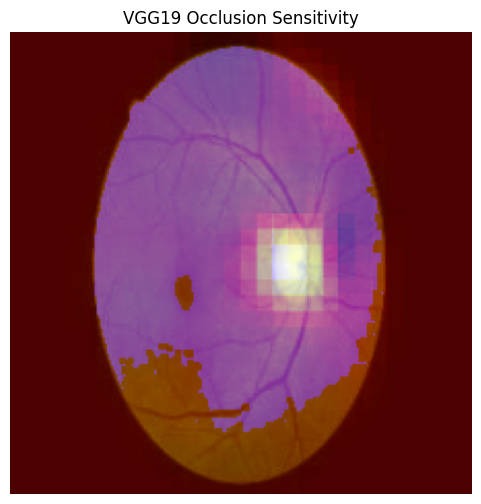

In [ ]:
occlusion = Occlusion(model_vgg19)
attr_occ = occlusion.attribute(sample_img_tensor, target=sample_label,
                               sliding_window_shapes=(3,15,15), strides=(3,8,8))
heatmap_occ = attr_occ[0].sum(dim=0).cpu().detach().numpy()
heatmap_occ = (heatmap_occ - heatmap_occ.min()) / (heatmap_occ.max() - heatmap_occ.min())
superimposed_occ = overlay_heatmap_on_image(orig_img, heatmap_occ, alpha=0.4)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_occ)
plt.title("VGG19 Occlusion Sensitivity")
plt.axis('off')
plt.show()

DeepLIFT

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


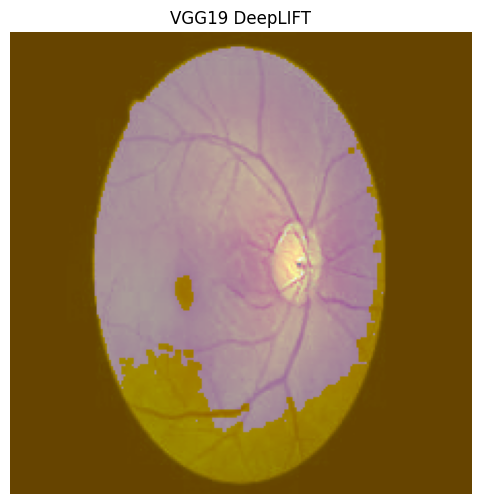

In [ ]:
deeplift = DeepLift(model_vgg19)
attr_dl = deeplift.attribute(
    sample_img_tensor,
    baselines=torch.zeros_like(sample_img_tensor),
    target=sample_label
)
heatmap_dl = attr_dl[0].sum(dim=0).cpu().detach().numpy()
heatmap_dl = (heatmap_dl - heatmap_dl.min()) / (heatmap_dl.max() - heatmap_dl.min())

superimposed_dl = overlay_heatmap_on_image(orig_img, heatmap_dl, alpha=0.4, colormap=cv2.COLORMAP_HOT)
plt.figure(figsize=(6,6))
plt.imshow(superimposed_dl)
plt.title("VGG19 DeepLIFT")
plt.axis('off')
plt.show()


#**Inference:**
| Model           | Accuracy | Macro F1 | Weighted F1 | Strengths                                           |
| --------------- | -------- | -------- | ----------- | ----------------------------------------------------------- |
| GNN + Conformer | 0.78     | 0.76     | 0.76        | Good for diabetic_retinopathy, struggles on glaucoma.       |
| ResNet50        | 0.86     | 0.85     | 0.85        | Balanced across classes, strong overall.                    |
| EfficientNet    | 0.91     | 0.90     | 0.91        | Highest val accuracy, strong F1 on DR and glaucoma.         |
| ViT             | 0.87     | 0.87     | 0.87        | Excellent on DR, glaucoma slightly lower than VGG.          |
| VGG19           | 0.90     | 0.90     | 0.90        | Strongest overall, best F1 on glaucoma, cataract also high. |
